In [2]:
unit_hydrograph = [0, 5, 11.67, 8.33, 1.67, 0]  # For 1 cm rainfall

In [3]:
rainfall = [1, 2, 0]  # Over 3 time intervals (e.g., 6 hours each)

In [4]:
import numpy as np

def compute_runoff_hydrograph(unit_hydrograph, rainfall):
    """
    Compute the direct runoff hydrograph using convolution.

    Parameters:
    unit_hydrograph (list): Unit hydrograph values (for 1 cm of rainfall)
    rainfall (list): Effective rainfall in cm over each interval

    Returns:
    list: Direct runoff hydrograph (m³/s)
    """
    # Perform discrete convolution
    drh = np.convolve(rainfall, unit_hydrograph)
    return list(drh)

# Define the unit hydrograph and rainfall
unit_hydrograph = [0, 5, 11.67, 8.33, 1.67, 0]  # Example: for 1 cm
rainfall = [1, 2, 0]  # Effective rainfall in cm

# Calculate DRH
runoff_hydrograph = compute_runoff_hydrograph(unit_hydrograph, rainfall)

# Print results
print("Direct Runoff Hydrograph (m³/s):")
for i, q in enumerate(runoff_hydrograph):
    print(f"Time {i * 6}–{(i + 1) * 6} hr: {q:.2f} m³/s")

Direct Runoff Hydrograph (m³/s):
Time 0–6 hr: 0.00 m³/s
Time 6–12 hr: 5.00 m³/s
Time 12–18 hr: 21.67 m³/s
Time 18–24 hr: 31.67 m³/s
Time 24–30 hr: 18.33 m³/s
Time 30–36 hr: 3.34 m³/s
Time 36–42 hr: 0.00 m³/s
Time 42–48 hr: 0.00 m³/s


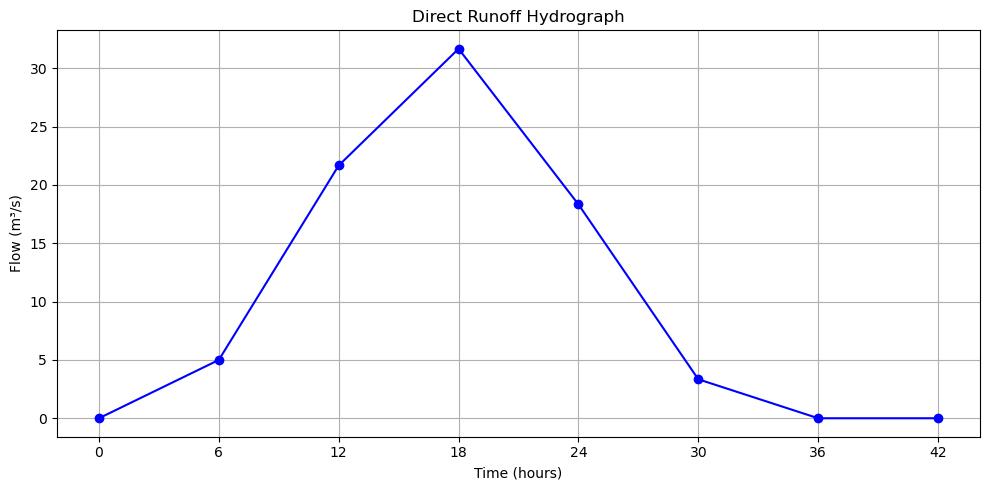

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def compute_runoff_hydrograph(unit_hydrograph, rainfall):
    return list(np.convolve(rainfall, unit_hydrograph))

# Example Unit Hydrograph (6-hour intervals, for 1 cm of rain)
unit_hydrograph = [0, 5, 11.67, 8.33, 1.67, 0]

# Example effective rainfall (in cm)
rainfall = [1, 2, 0]  # Total duration = 3 intervals × 6 hrs = 18 hrs

# Compute direct runoff hydrograph
runoff_hydrograph = compute_runoff_hydrograph(unit_hydrograph, rainfall)

# Generate time axis (in hours, assuming 6-hour intervals)
interval_hours = 6
time = [i * interval_hours for i in range(len(runoff_hydrograph))]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time, runoff_hydrograph, marker='o', linestyle='-', color='blue')
plt.title('Direct Runoff Hydrograph')
plt.xlabel('Time (hours)')
plt.ylabel('Flow (m³/s)')
plt.grid(True)
plt.xticks(time)
plt.tight_layout()
plt.show()

In [1]:
#calibration

NSE:  0.982
RMSE: 1.395
MAE:  1.096


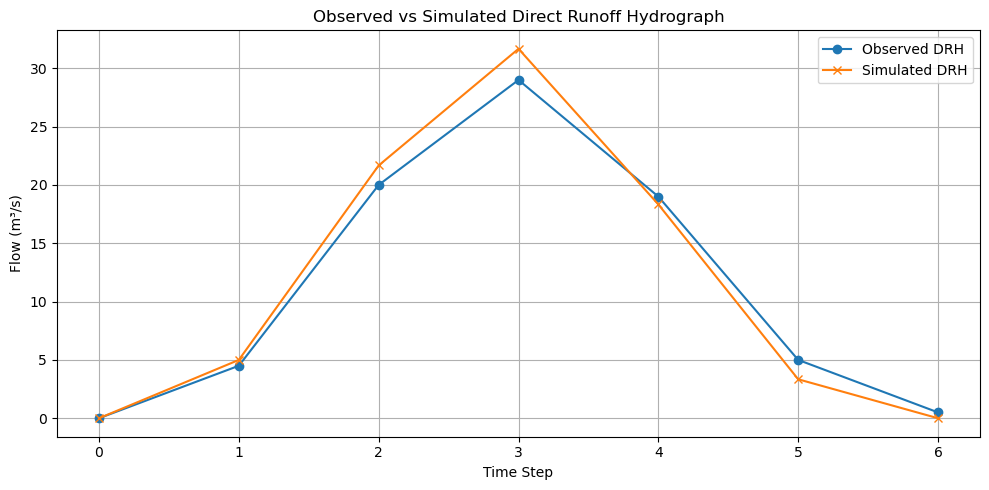

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated DRH (from UH + effective rainfall)
simulated = np.array([0, 5, 21.67, 31.67, 18.33, 3.34, 0])

# Observed DRH (from gauging station, after baseflow removal)
observed = np.array([0, 4.5, 20, 29, 19, 5, 0.5])

# Performance metrics
def evaluate_fit(obs, sim):
    nse = 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)
    rmse = np.sqrt(np.mean((obs - sim)**2))
    mae = np.mean(np.abs(obs - sim))
    return nse, rmse, mae

nse, rmse, mae = evaluate_fit(observed, simulated)

print(f"NSE:  {nse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")

# Plot observed vs simulated
plt.figure(figsize=(10, 5))
plt.plot(observed, label="Observed DRH", marker='o')
plt.plot(simulated, label="Simulated DRH", marker='x')
plt.title("Observed vs Simulated Direct Runoff Hydrograph")
plt.xlabel("Time Step")
plt.ylabel("Flow (m³/s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()